# Chapter 1 - Polygon Triangulation

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 1, printed pages 1-43: polygon definitions, the art gallery theorem, triangulation theory, polygon area, implementation representations, segment intersection predicates, and the ear-clipping triangulation implementation. The goal is not to reproduce the book's presentation. Instead, the notebook rebuilds the chapter as a runnable geometry lab: every major idea gets a small data structure, a diagram, and a check that can fail when a hypothesis is changed.

The chapter starts with a simple but unforgiving object: a polygon is a closed chain of segments with a well-defined inside and outside. That sentence hides several algorithmic commitments. We need an orientation predicate for left/right tests, an area convention, a way to tell when two segments meet, and a representation that lets the previous and next vertices of a boundary point be found quickly. Those primitives are then reused in the art gallery theorem and in triangulation. If the polygon can be triangulated, its triangulation graph has `n-3` internal diagonals and `n-2` triangles; the weak dual is a tree; an ear exists at least twice; and a 3-coloring of the triangulation graph gives a guard set of size at most `floor(n/3)` by choosing the smallest color class.

The code below deliberately uses compact synthetic polygons rather than copied textbook figures. The same small polygon is pushed through several viewpoints: signed area and Jordan-style ray parity, diagonal visibility, ear removal, dual-tree structure, color guarding, and robust intersection categories. This keeps the notebook standalone: a reader should be able to understand why the C predicates are needed, how the triangulation proof becomes an algorithm, and where the art gallery bound gets its combinatorial force.


## Visual Storyboard

1. **Inside, outside, and signed area.** A Jordan-style ray probe and a shoelace-area fan show why polygon computations need a consistent orientation convention.
2. **Predicate board.** `orient`, `left`, `left_on`, `collinear`, `between`, and segment intersection categories are implemented as the Python analog of the C predicate layer.
3. **Ear clipping trace.** The polygon is triangulated by repeatedly removing visible convex ears; checks confirm `n-2` triangles and `n-3` diagonals.
4. **Triangulation dual tree.** Adjacent triangles form the weak dual, and its tree property is the graph-theoretic shadow of the two-ears theorem.
5. **Fisk coloring and guards.** The triangulation graph is 3-colored; the smallest color class becomes a guard set and is checked against `floor(n/3)`.
6. **Implementation failure modes.** Segment cases include proper crossing, endpoint touch, overlapping collinear segments, and disjoint segments, so later chapters can reuse the distinction between proper and improper intersections.


## Library Routing

The chapter is algorithmic rather than numerical-heavy, so the notebook keeps the libraries modest. `numpy` stores points and does determinant arithmetic, `matplotlib` draws the polygon states, and `networkx` carries the triangulation graph and its dual. The book-local artifact helpers save figures, tables, and JSON checks under `Computational-Geometry-in-C/artifacts/chapter-01-polygon-triangulation/`, which makes the outputs auditable without relying on notebook cell output alone. No external geometry engine is used for the core predicates: the point of the chapter is to see the orientation and segment tests directly.


In [1]:
# setup
from __future__ import annotations
import json, math, sys
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-01-polygon-triangulation"
UNIT_TITLE = "Polygon Triangulation"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

storyboard = [
    {"move": "area-and-parity", "visual": "polygon-area-parity.png", "check": "shoelace_area_matches_triangle_fan"},
    {"move": "predicate-board", "visual": "segment-predicate-board.png", "check": "proper_endpoint_overlap_disjoint_cases_classified"},
    {"move": "ear-clipping", "visual": "ear-clipping-triangulation.png", "check": "n_minus_two_triangles"},
    {"move": "dual-tree", "visual": "triangulation-dual-tree.png", "check": "dual_is_tree"},
    {"move": "fisk-coloring", "visual": "fisk-guard-coloring.png", "check": "least_color_class_at_most_floor_n_over_3"},
]
routing_rows = [
    {"source_topic": "Jordan curve and polygon representation", "artifact": "polygon-area-parity.png", "code_cell": "area and parity"},
    {"source_topic": "Left, LeftOn, Collinear, Between, Intersect", "artifact": "segment-predicate-board.png", "code_cell": "predicate board"},
    {"source_topic": "Diagonal, InCone, ears", "artifact": "ear-clipping-triangulation.png", "code_cell": "ear clipping"},
    {"source_topic": "Triangulation dual and two ears", "artifact": "triangulation-dual-tree.png", "code_cell": "dual graph"},
    {"source_topic": "Fisk proof of art gallery theorem", "artifact": "fisk-guard-coloring.png", "code_cell": "guard coloring"},
]

storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 1-43", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "1-43", "pdf_pages": "10-52"},
    "covered_ideas": [
        "polygon/Jordan inside-outside convention",
        "art gallery theorem and Fisk coloring proof",
        "diagonal existence, ears, and triangulation counts",
        "shoelace and triangle-fan signed area",
        "C-style orientation and segment intersection predicates",
        "ear-clipping implementation and O(n^2) behavior",
    ],
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "storyboard_items": len(storyboard)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-01-polygon-triangulation",
  "storyboard_items": 5
}


## Predicate Layer

The implementation sections of the chapter are not incidental; they are the bridge from theorem statements to code. A diagonal is not just a segment drawn between two vertices. It has to lie inside the polygon and avoid all boundary edges except at its endpoints. An ear is not just a visually plausible triangle; it needs a convex tip and an empty interior. The art gallery coloring is not just a coloring of an arbitrary graph; it is a coloring of the maximal outerplanar graph created by a triangulation.

The functions in the next cell mirror the book's C vocabulary in Python form. `area2(a,b,c)` is the signed twice-area determinant. `left`, `left_on`, and `collinear` make orientation tests explicit. `between` is used only after collinearity is known. `segments_intersect` distinguishes the proper crossing case from endpoint and overlap cases. These distinctions matter immediately for triangulation and later return in the search/intersection chapter, where the actual point of intersection is also needed.


In [2]:
EPS = 1e-9

poly = np.array([
    [0.0, 0.0], [3.0, 0.15], [3.35, 1.2], [2.2, 1.05],
    [2.05, 2.35], [1.25, 1.55], [0.25, 2.35], [-0.35, 1.1]
], dtype=float)

def area2(a, b, c):
    a, b, c = map(np.asarray, (a, b, c))
    return float(np.cross(b - a, c - a))

def polygon_area(points):
    pts = np.asarray(points)
    return 0.5 * float(np.sum(pts[:, 0] * np.roll(pts[:, 1], -1) - np.roll(pts[:, 0], -1) * pts[:, 1]))

def left(a, b, c):
    return area2(a, b, c) > EPS

def left_on(a, b, c):
    return area2(a, b, c) >= -EPS

def collinear(a, b, c):
    return abs(area2(a, b, c)) <= EPS

def between(a, b, c):
    if not collinear(a, b, c):
        return False
    return (min(a[0], b[0]) - EPS <= c[0] <= max(a[0], b[0]) + EPS and
            min(a[1], b[1]) - EPS <= c[1] <= max(a[1], b[1]) + EPS)

def segment_kind(a, b, c, d):
    o1, o2, o3, o4 = area2(a, b, c), area2(a, b, d), area2(c, d, a), area2(c, d, b)
    if (o1 > EPS and o2 < -EPS or o1 < -EPS and o2 > EPS) and (o3 > EPS and o4 < -EPS or o3 < -EPS and o4 > EPS):
        return "proper"
    touches = []
    for point, name in [(c, "c_on_ab"), (d, "d_on_ab")]:
        if between(a, b, point):
            touches.append(name)
    for point, name in [(a, "a_on_cd"), (b, "b_on_cd")]:
        if between(c, d, point):
            touches.append(name)
    if touches and collinear(a, b, c) and collinear(a, b, d):
        return "collinear-overlap"
    if touches:
        return "endpoint-touch"
    return "disjoint"

def point_in_polygon(point, vertices):
    x, y = point
    inside = False
    for a, b in zip(vertices, np.roll(vertices, -1, axis=0)):
        yi, yj = a[1], b[1]
        if ((yi > y) != (yj > y)):
            x_hit = a[0] + (y - yi) * (b[0] - a[0]) / (yj - yi)
            if x_hit > x:
                inside = not inside
    return inside

if polygon_area(poly) < 0:
    poly = poly[::-1].copy()

predicate_cases = [
    {"case": "proper", "a": (0, 0), "b": (3, 2), "c": (0, 2), "d": (3, 0)},
    {"case": "endpoint-touch", "a": (0, 0), "b": (2, 0), "c": (2, 0), "d": (3, 1)},
    {"case": "collinear-overlap", "a": (0, 0), "b": (3, 0), "c": (1, 0), "d": (4, 0)},
    {"case": "disjoint", "a": (0, 0), "b": (1, 0), "c": (2, 0.4), "d": (3, 0.7)},
]
for row in predicate_cases:
    row["observed"] = segment_kind(np.array(row["a"], float), np.array(row["b"], float), np.array(row["c"], float), np.array(row["d"], float))

predicate_path = save_json({"cases": predicate_cases, "all_cases_match": all(r["case"] == r["observed"] for r in predicate_cases)}, CHECKS / "predicate-cases.json")
print(json.dumps({"polygon_area": polygon_area(poly), "predicate_cases_match": all(r["case"] == r["observed"] for r in predicate_cases)}, indent=2))


{
  "polygon_area": 5.44,
  "predicate_cases_match": true
}


C:\Users\rahul\AppData\Local\Temp\ipykernel_38212\4018116213.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(b - a, c - a))


## Area, Parity, and the Boundary Convention

The area formula is often remembered as a determinant trick, but in this chapter it also serves as a consistency check for orientation. A counterclockwise polygon has positive signed area. Triangulating the polygon from a fixed interior point produces signed triangle areas whose sum equals the shoelace area. The equality works because adjacent triangles cancel the artificial spokes. This is the same cancellation idea that makes a robust implementation prefer determinant predicates over slopes: the geometry is local, but the invariant is global.

The ray-parity test in the plot is not used later as the primary point-in-polygon method, but it makes the inside/outside convention visible. A horizontal ray from a query point crosses the boundary an odd number of times when the point is inside and an even number of times when it is outside. Degenerate hits at vertices need careful handling in production code; here the chosen query avoids that ambiguity so the visual focuses on the Jordan-curve logic rather than edge-case bookkeeping.


C:\Users\rahul\AppData\Local\Temp\ipykernel_38212\4018116213.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(b - a, c - a))


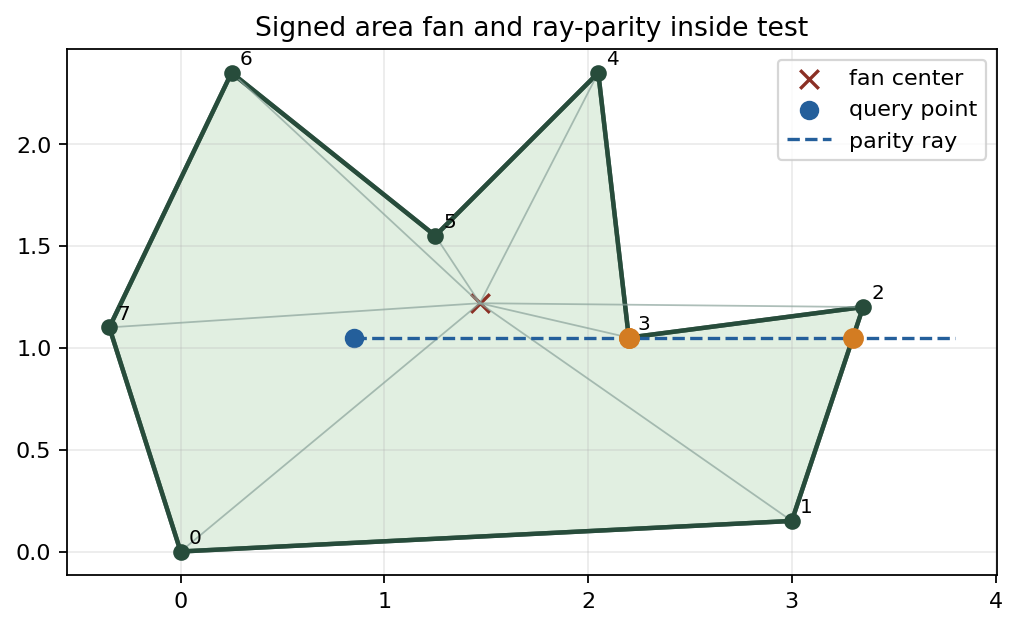

{
  "n_vertices": 8,
  "shoelace_area": 5.44,
  "triangle_fan_area": 5.44,
  "ray_hits_to_right": 3,
  "query_inside_by_parity": true,
  "checks": {
    "shoelace_area_matches_triangle_fan": true,
    "ccw_orientation": true,
    "odd_ray_hits_for_inside_query": true
  }
}


In [3]:
centroid = poly.mean(axis=0)
tri_fan = [(centroid, poly[i], poly[(i + 1) % len(poly)]) for i in range(len(poly))]
fan_area = sum(area2(*tri) / 2 for tri in tri_fan)
shoelace_area = polygon_area(poly)
query = np.array([0.85, 1.05])
ray_y = query[1]
ray_hits = []
for a, b in zip(poly, np.roll(poly, -1, axis=0)):
    if (a[1] > ray_y) != (b[1] > ray_y):
        x_hit = a[0] + (ray_y - a[1]) * (b[0] - a[0]) / (b[1] - a[1])
        if x_hit > query[0]:
            ray_hits.append((x_hit, ray_y))

fig, ax = plt.subplots(figsize=(7.5, 5.4))
closed = np.vstack([poly, poly[0]])
ax.fill(poly[:, 0], poly[:, 1], color="#d8ead7", alpha=0.75, edgecolor="#274c3b", linewidth=2)
ax.plot(closed[:, 0], closed[:, 1], color="#274c3b", linewidth=2)
for i, p in enumerate(poly):
    ax.scatter(*p, color="#274c3b", s=42, zorder=3)
    ax.text(p[0] + 0.04, p[1] + 0.04, str(i), fontsize=9)
for _, a, b in tri_fan:
    ax.plot([centroid[0], a[0]], [centroid[1], a[1]], color="#8aa39b", linewidth=0.8, alpha=0.7)
ax.scatter(*centroid, marker="x", color="#8b2f24", s=70, label="fan center")
ax.scatter(*query, color="#245f9b", s=60, label="query point")
ax.plot([query[0], 3.8], [query[1], query[1]], color="#245f9b", linestyle="--", linewidth=1.5, label="parity ray")
for hit in ray_hits:
    ax.scatter(*hit, color="#d37c22", s=70, zorder=4)
ax.set_title("Signed area fan and ray-parity inside test")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
area_fig_path = save_matplotlib(fig, FIGURES / "polygon-area-parity.png")
plt.close(fig)

area_report = {
    "n_vertices": int(len(poly)),
    "shoelace_area": shoelace_area,
    "triangle_fan_area": fan_area,
    "ray_hits_to_right": len(ray_hits),
    "query_inside_by_parity": point_in_polygon(query, poly),
    "checks": {
        "shoelace_area_matches_triangle_fan": abs(shoelace_area - fan_area) < 1e-9,
        "ccw_orientation": shoelace_area > 0,
        "odd_ray_hits_for_inside_query": len(ray_hits) % 2 == 1 and point_in_polygon(query, poly),
    },
}
area_path = save_json(area_report, CHECKS / "area-and-parity.json")
display_artifact(area_fig_path, width=740)
print(json.dumps(area_report, indent=2))


## Ear Clipping as an Algorithmic Proof

The triangulation theorem says every polygon has a triangulation; the implementation asks how to find one. Ear clipping turns the existence proof into a loop. At each step, a convex vertex whose ear triangle contains no other polygon vertex can be cut away. For a simple polygon this process eventually leaves one triangle. The code records the removal order, diagonals, and triangle list. The checks are deliberately the chapter's theorem-level checks: a polygon with `n` vertices should produce `n-2` triangles and `n-3` internal diagonals, and the sum of triangle areas should match the polygon area.

The function is intentionally small enough to inspect. It does not aim to be a production geometry kernel, and it avoids copied C code. Instead it exposes the control logic that the C implementation later refines with circular doubly-linked lists, `InCone`, `Diagonalie`, and exact predicate choices. The visual makes the proof computational: every triangle was once an ear, and each diagonal is a stored decision.


C:\Users\rahul\AppData\Local\Temp\ipykernel_38212\4018116213.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(b - a, c - a))


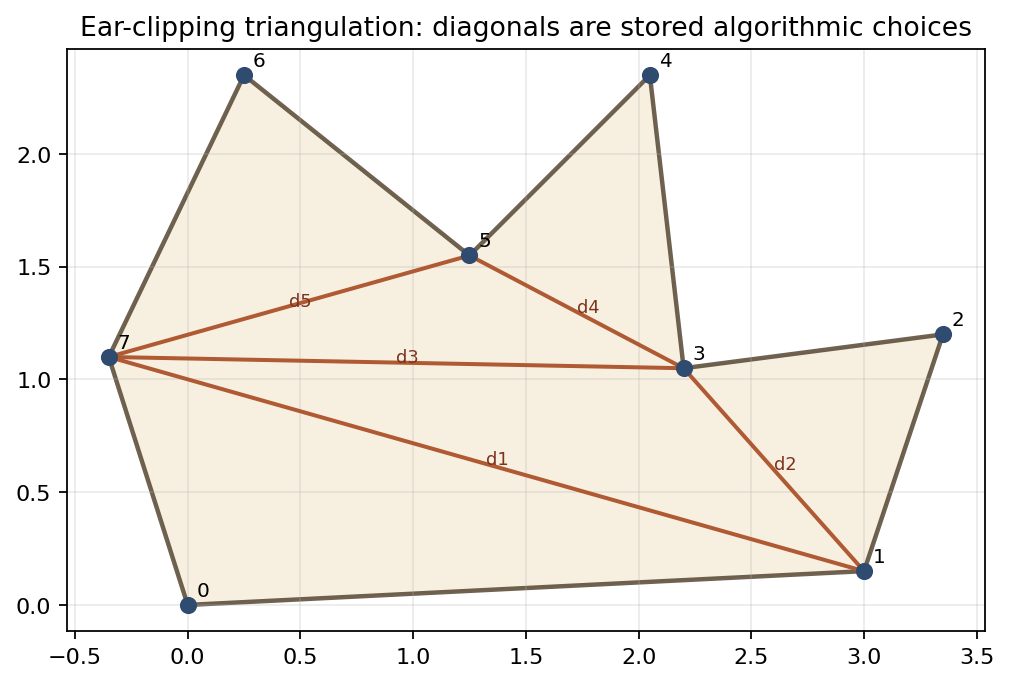

{
  "n_minus_two_triangles": true,
  "n_minus_three_diagonals": true,
  "triangles_cover_area": true
}


In [4]:
def point_in_triangle(p, a, b, c):
    s1, s2, s3 = area2(a, b, p), area2(b, c, p), area2(c, a, p)
    has_neg = (s1 < -EPS) or (s2 < -EPS) or (s3 < -EPS)
    has_pos = (s1 > EPS) or (s2 > EPS) or (s3 > EPS)
    return not (has_neg and has_pos)

def ear_clip(vertices):
    vertices = np.asarray(vertices, dtype=float)
    if polygon_area(vertices) < 0:
        vertices = vertices[::-1].copy()
    remaining = list(range(len(vertices)))
    triangles = []
    diagonals = []
    removal_order = []
    guard = 0
    while len(remaining) > 3:
        guard += 1
        if guard > len(vertices) ** 2:
            raise RuntimeError("ear search stalled")
        clipped = False
        m = len(remaining)
        for pos, curr in enumerate(remaining):
            prev_i = remaining[(pos - 1) % m]
            next_i = remaining[(pos + 1) % m]
            a, b, c = vertices[prev_i], vertices[curr], vertices[next_i]
            if area2(a, b, c) <= EPS:
                continue
            others = [idx for idx in remaining if idx not in {prev_i, curr, next_i}]
            if any(point_in_triangle(vertices[idx], a, b, c) for idx in others):
                continue
            triangles.append((prev_i, curr, next_i))
            diagonals.append((prev_i, next_i))
            removal_order.append({"ear_tip": int(curr), "diagonal": [int(prev_i), int(next_i)], "remaining_before_clip": int(m)})
            del remaining[pos]
            clipped = True
            break
        if not clipped:
            raise RuntimeError("no visible ear found")
    triangles.append(tuple(remaining))
    true_diagonals = diagonals[:-1] if len(diagonals) == len(vertices) - 2 else diagonals
    return triangles, true_diagonals, removal_order

triangles, diagonals, removal_order = ear_clip(poly)
triangle_area_sum = sum(abs(area2(poly[i], poly[j], poly[k]) / 2) for i, j, k in triangles)
triangulation_edges = set()
for i in range(len(poly)):
    triangulation_edges.add(tuple(sorted((i, (i + 1) % len(poly)))))
for i, j in diagonals:
    triangulation_edges.add(tuple(sorted((i, j))))

fig, ax = plt.subplots(figsize=(7.4, 5.6))
ax.fill(poly[:, 0], poly[:, 1], color="#f6edd9", alpha=0.8, edgecolor="#4b3b26", linewidth=2)
for step, (i, j) in enumerate(diagonals, 1):
    ax.plot([poly[i, 0], poly[j, 0]], [poly[i, 1], poly[j, 1]], color="#b05a34", linewidth=1.8)
    mid = (poly[i] + poly[j]) / 2
    ax.text(mid[0], mid[1], f"d{step}", fontsize=8, color="#7d321d")
for i, p in enumerate(poly):
    ax.scatter(*p, color="#2f4b6f", s=45, zorder=4)
    ax.text(p[0] + 0.04, p[1] + 0.04, str(i), fontsize=9)
ax.set_title("Ear-clipping triangulation: diagonals are stored algorithmic choices")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ear_fig_path = save_matplotlib(fig, FIGURES / "ear-clipping-triangulation.png")
plt.close(fig)

ear_rows = [
    {"step": step + 1, "ear_tip": row["ear_tip"], "diagonal": f"{row['diagonal'][0]}-{row['diagonal'][1]}", "remaining_before_clip": row["remaining_before_clip"]}
    for step, row in enumerate(removal_order)
]
ear_table_path = save_csv(ear_rows, TABLES / "ear-clipping-removal-order.csv")
ear_report = {
    "n_vertices": int(len(poly)),
    "triangles": [list(map(int, tri)) for tri in triangles],
    "diagonals": [list(map(int, edge)) for edge in diagonals],
    "triangle_area_sum": triangle_area_sum,
    "polygon_area": shoelace_area,
    "checks": {
        "n_minus_two_triangles": len(triangles) == len(poly) - 2,
        "n_minus_three_diagonals": len(diagonals) == len(poly) - 3,
        "triangles_cover_area": abs(triangle_area_sum - shoelace_area) < 1e-9,
    },
}
ear_path = save_json(ear_report, CHECKS / "ear-clipping-checks.json")
display_artifact(ear_fig_path, width=740)
print(json.dumps(ear_report["checks"], indent=2))


## Dual Tree, Two Ears, and Fisk Coloring

Once the polygon is triangulated, the chapter's proof structure becomes graph theory. Create one node for each triangle, and connect two nodes when the corresponding triangles share a diagonal. That weak dual should be a tree. Leaves in this tree correspond to ears: triangles with only one internal adjacency. Seeing the dual tree is a good way to remember why ear removal is possible and why recursive arguments on polygon triangulations are natural.

Fisk's proof of the art gallery theorem adds one more graph layer. Build the triangulation graph on polygon vertices, then 3-color it so every triangle has three colors. One of the color classes has at most `floor(n/3)` vertices. Placing guards at those vertices covers every triangle, and because the triangles cover the polygon, the guards cover the polygon. The notebook checks the two claims that matter: no triangle is missing a color, and the selected color class respects the floor bound.


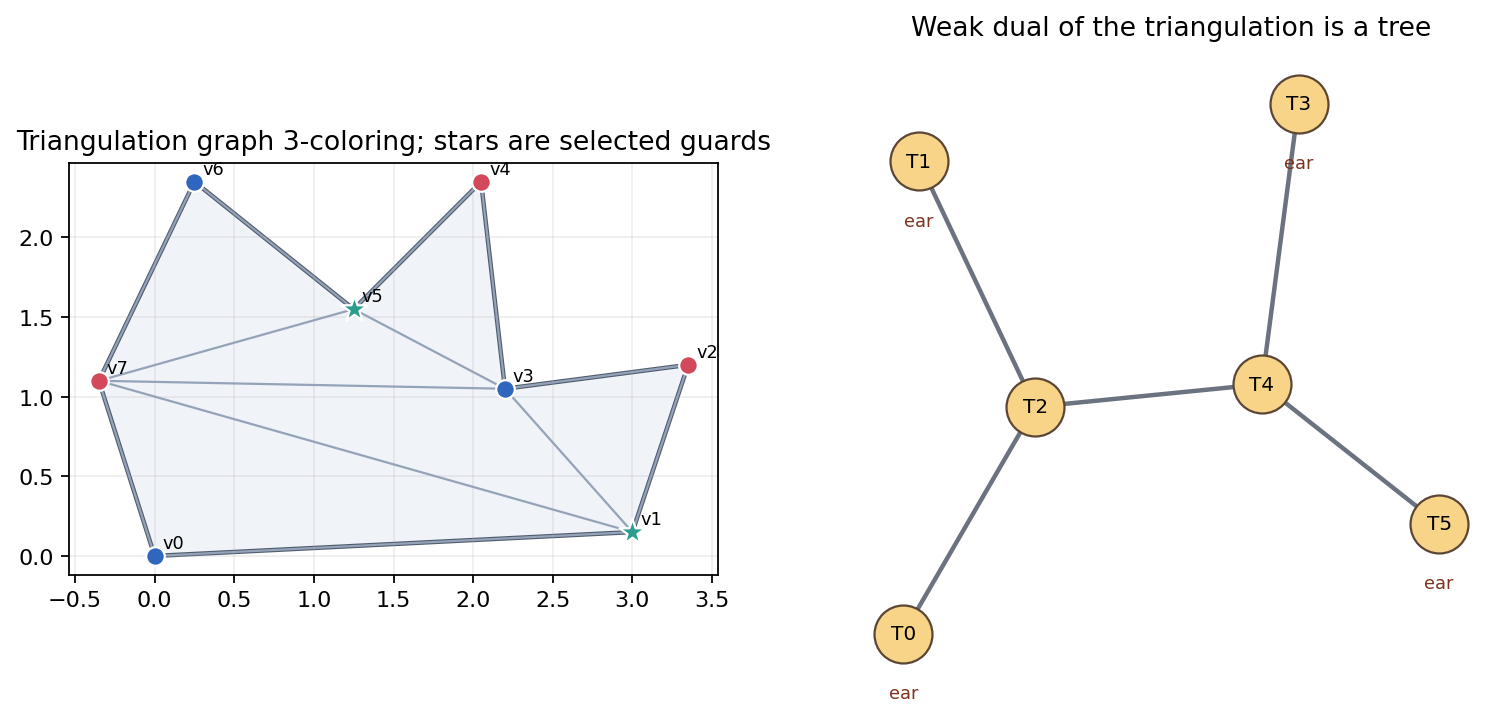

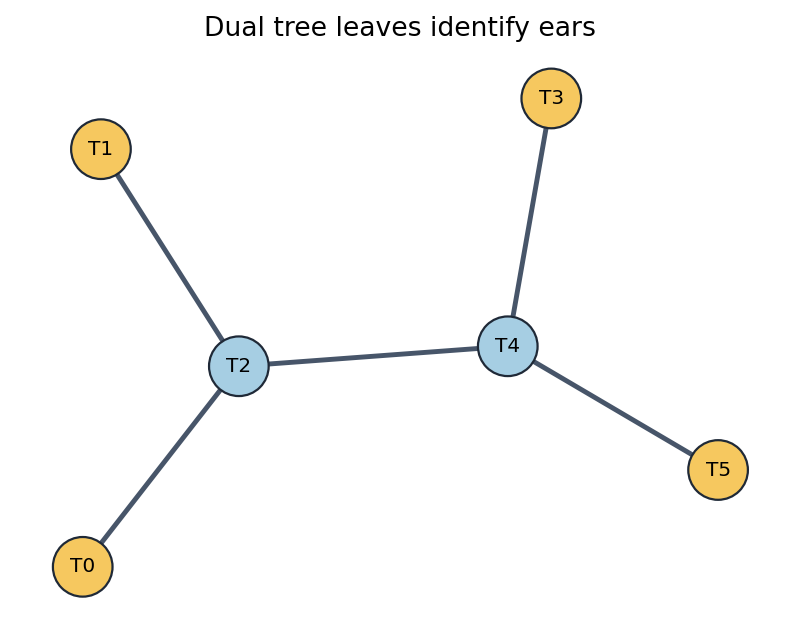

{
  "color_classes": {
    "0": [
      0,
      3,
      6
    ],
    "1": [
      2,
      4,
      7
    ],
    "2": [
      1,
      5
    ]
  },
  "selected_guard_color": 2,
  "guards": [
    1,
    5
  ],
  "dual_tree_edges": 5,
  "dual_tree_nodes": 6,
  "ear_leaf_count": 4,
  "checks": {
    "three_colors_used": true,
    "each_triangle_has_three_colors": true,
    "least_color_class_at_most_floor_n_over_3": true,
    "dual_is_tree": true,
    "at_least_two_ears": true
  }
}


In [5]:
Tdual = nx.Graph()
for idx, tri in enumerate(triangles):
    Tdual.add_node(idx, triangle=tri)
for i, tri_a in enumerate(triangles):
    set_a = set(tri_a)
    for j in range(i + 1, len(triangles)):
        if len(set_a.intersection(triangles[j])) == 2:
            Tdual.add_edge(i, j)

Gtri = nx.Graph()
Gtri.add_nodes_from(range(len(poly)))
Gtri.add_edges_from(triangulation_edges)
coloring = nx.greedy_color(Gtri, strategy="largest_first")
used_colors = sorted(set(coloring.values()))
color_classes = {color: sorted(v for v, c in coloring.items() if c == color) for color in used_colors}
guard_color = min(color_classes, key=lambda c: len(color_classes[c]))
guards = color_classes[guard_color]
triangles_have_three_colors = all(len({coloring[v] for v in tri}) == 3 for tri in triangles)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
ax = axes[0]
ax.fill(poly[:, 0], poly[:, 1], color="#eef2f7", alpha=0.85, edgecolor="#334155", linewidth=2)
palette = {0: "#3066be", 1: "#d1495b", 2: "#2a9d8f", 3: "#f4a261"}
for edge in triangulation_edges:
    i, j = edge
    ax.plot([poly[i, 0], poly[j, 0]], [poly[i, 1], poly[j, 1]], color="#94a3b8", linewidth=1)
for v, p in enumerate(poly):
    size = 150 if v in guards else 70
    marker = "*" if v in guards else "o"
    ax.scatter(*p, color=palette[coloring[v]], s=size, marker=marker, edgecolor="white", linewidth=1.0, zorder=4)
    ax.text(p[0] + 0.05, p[1] + 0.05, f"v{v}", fontsize=8)
ax.set_title("Triangulation graph 3-coloring; stars are selected guards")
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)

ax = axes[1]
pos = nx.spring_layout(Tdual, seed=11)
nx.draw_networkx_nodes(Tdual, pos, node_color="#f7d488", edgecolors="#5b4636", node_size=680, ax=ax)
nx.draw_networkx_edges(Tdual, pos, width=2, edge_color="#6b7280", ax=ax)
nx.draw_networkx_labels(Tdual, pos, labels={i: f"T{i}" for i in Tdual.nodes}, font_size=9, ax=ax)
leaf_nodes = [node for node, deg in Tdual.degree() if deg == 1]
for node in leaf_nodes:
    x, y = pos[node]
    ax.text(x, y - 0.13, "ear", ha="center", fontsize=8, color="#7d321d")
ax.set_title("Weak dual of the triangulation is a tree")
ax.axis("off")

guard_fig_path = save_matplotlib(fig, FIGURES / "fisk-guard-coloring.png")
plt.close(fig)

fig, ax = plt.subplots(figsize=(6.2, 4.6))
nx.draw_networkx_nodes(Tdual, pos, node_color=["#f6c85f" if n in leaf_nodes else "#a6cee3" for n in Tdual.nodes], edgecolors="#1f2937", node_size=720, ax=ax)
nx.draw_networkx_edges(Tdual, pos, width=2.2, edge_color="#475569", ax=ax)
nx.draw_networkx_labels(Tdual, pos, labels={i: f"T{i}" for i in Tdual.nodes}, font_size=9, ax=ax)
ax.set_title("Dual tree leaves identify ears")
ax.axis("off")
dual_fig_path = save_matplotlib(fig, FIGURES / "triangulation-dual-tree.png")
plt.close(fig)

guard_report = {
    "color_classes": {str(k): v for k, v in color_classes.items()},
    "selected_guard_color": int(guard_color),
    "guards": [int(v) for v in guards],
    "dual_tree_edges": int(Tdual.number_of_edges()),
    "dual_tree_nodes": int(Tdual.number_of_nodes()),
    "ear_leaf_count": int(len(leaf_nodes)),
    "checks": {
        "three_colors_used": len(used_colors) <= 3,
        "each_triangle_has_three_colors": triangles_have_three_colors,
        "least_color_class_at_most_floor_n_over_3": len(guards) <= math.floor(len(poly) / 3),
        "dual_is_tree": nx.is_tree(Tdual),
        "at_least_two_ears": len(leaf_nodes) >= 2,
    },
}
guard_path = save_json(guard_report, CHECKS / "fisk-guard-coloring.json")
display_artifact(guard_fig_path, width=900)
display_artifact(dual_fig_path, width=620)
print(json.dumps(guard_report, indent=2))


## Segment Intersection Board

The triangulation implementation avoids invalid diagonals by asking whether a proposed diagonal hits the polygon boundary. That is why the early predicate work is so important. Slope comparisons are brittle, especially for vertical segments and nearly parallel lines; determinant signs are the stable language. The cases below are not a replacement for a full exact-arithmetic kernel, but they form a useful test board for the chapter's C routines: proper crossings, endpoint contacts, collinear overlaps, and nonintersections must not collapse into one vague Boolean if downstream algorithms care about the difference.


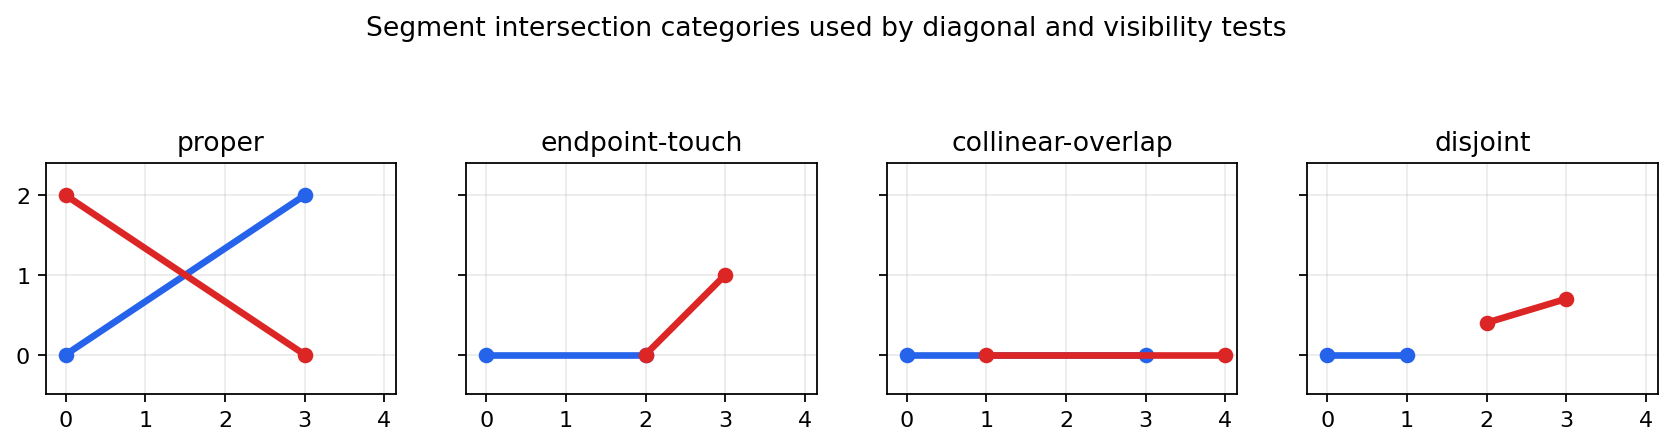

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4), sharex=True, sharey=True)
for ax, row in zip(axes, predicate_cases):
    a, b, c, d = [np.array(row[key], float) for key in ["a", "b", "c", "d"]]
    ax.plot([a[0], b[0]], [a[1], b[1]], color="#2563eb", linewidth=3, marker="o")
    ax.plot([c[0], d[0]], [c[1], d[1]], color="#dc2626", linewidth=3, marker="o")
    ax.set_title(row["observed"])
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(-0.25, 4.15)
    ax.set_ylim(-0.5, 2.4)
fig.suptitle("Segment intersection categories used by diagonal and visibility tests")
predicate_fig_path = save_matplotlib(fig, FIGURES / "segment-predicate-board.png")
plt.close(fig)
predicate_table_path = save_csv(predicate_cases, TABLES / "segment-predicate-cases.csv")
display_artifact(predicate_fig_path, width=980)


## Applied Lab

A good experiment is to move a single vertex and rerun the notebook. If a convex ear becomes reflex, the ear removal order should change. If the polygon becomes self-intersecting, the area and triangulation checks are no longer meaningful, which is exactly the warning the chapter gives by insisting on a polygon representation before algorithm design. If a segment predicate is weakened from `left_on` to strict `left`, endpoint-touch cases will be misclassified; that kind of tiny predicate change can break diagonal tests without changing the visual much.

For a second experiment, try adding one more notch to the polygon. The theorem-level counts should update automatically to `n-2` and `n-3`, while the smallest color class should still be at most `floor(n/3)`. The purpose is not to manufacture a harder picture. It is to watch the chapter's invariants survive changes that preserve the hypotheses and fail when the hypotheses are violated.


## Takeaways

The chapter's central message is that triangulation is both a theorem and a programming interface. The theorem guarantees that polygons can be decomposed into triangles; the interface asks for orientation tests, segment intersection classification, area accounting, and a mutable boundary representation. Ear clipping is slow compared with the best known triangulation algorithms, but it is transparent and pairs naturally with the proof that every polygon has ears. The art gallery theorem then arrives almost for free once the triangulation graph is 3-colored: every triangle has one vertex of each color, so the smallest color class sees the whole polygon.

The checks in this notebook are deliberately simple: area conservation, `n-2` triangles, `n-3` diagonals, a tree-shaped weak dual, at least two ears, and a guard set no larger than `floor(n/3)`. They do not prove all cases, but they keep the implementation faithful to the source span and make the hidden dependencies visible. Later chapters reuse the same determinants, graphs, and visibility logic for partitioning, convex hulls, shortest paths, and intersection search.


In [7]:
# final_sanity
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 12,
    "checks": {
        **area_report["checks"],
        **ear_report["checks"],
        **guard_report["checks"],
        "predicate_cases_match": all(r["case"] == r["observed"] for r in predicate_cases),
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path), str(predicate_path),
        str(area_fig_path), str(area_path), str(ear_fig_path), str(ear_table_path), str(ear_path),
        str(guard_fig_path), str(dual_fig_path), str(guard_path), str(predicate_fig_path), str(predicate_table_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "shoelace_area_matches_triangle_fan": true,
    "ccw_orientation": true,
    "odd_ray_hits_for_inside_query": true,
    "n_minus_two_triangles": true,
    "n_minus_three_diagonals": true,
    "triangles_cover_area": true,
    "three_colors_used": true,
    "each_triangle_has_three_colors": true,
    "least_color_class_at_most_floor_n_over_3": true,
    "dual_is_tree": true,
    "at_least_two_ears": true,
    "predicate_cases_match": true
  }
}
